# AMS563 Homework 3 (Spring 2026) - Part 1

This assignment is for AMS563, Spring 2026. Complete all tasks in this notebook. Keep the structure unchanged and run all cells before submission.


## HW3 Part 1
---
While deep learning-based models are getting more and more complicated, it is relatively easy to run them. In this assignment part, we will try to use Faster R-CNN on a small subset of MS COCO images and YOLOv11 on a Cryo-EM dataset.

**Organizing the homework project files in your working space**
```
{last name}_{first name}_{sbu id}_hw3/
├── part1/
│   └── AMS563_24F_HW3_P1.ipynb
├── part2/
│   ├── AMS563_24F_HW3_P2.ipynb
│   └── detr/
├── part3/
│   ├── AMS563_24F_HW3_P3.ipynb
│   └── unet/
└── coco/
```

Create a directory named  `{last name}_{first name}_{sbu id}_hw3` and this will server as your `HW3_ROOT_PATH`.
Further you will have the 3 parts organized inside it as shown above. The coco dataset we will be using will also be in the root directory.

### MS COCO subset dataset

Through out the section 1 of homework 3 we will be using a small subset of MS COCO dataset (https://cocodataset.org/#home). Given the limited resources (gpu), you will only work on one class of objects: i.e, horses (why horses? you will see in part 2).Overall there are 500 images for training and 50 images for validation.

To load the dataset, place the coco.zip dataset at `HW3_ROOT_PATH`.

To pull this zip into your google drive, you have to first add the zip file as shortcut to root hw directory. To do this, open the above link and click on "Add shortcut to Drive" button (drive symbol with a plus) and navigate to correct path and add shortcut.

### Setting path variable

In [ ]:
HW3_ROOT_PATH = '/gdrive/MyDrive/AMS563/AMS563-25S-HW3/'

PATH_TO_PART1 = HW3_ROOT_PATH + 'part1/'
PATH_TO_COCO = HW3_ROOT_PATH + 'coco/'
# TRY to use these variable wherever you load/save some file



In [ ]:
from google.colab import drive
drive.mount('/gdrive')
# CD into root of your homework2 part3 directory
%cd -q $HW3_ROOT_PATH


Mounted at /gdrive


In [ ]:
!pip install colorama

### Unzip the dataset to ROOT/coco/

In [ ]:
!unzip -n coco.zip

unzip:  cannot find or open coco.zip, coco.zip.zip or coco.zip.ZIP.


## Part 1

In this part, you should use the above mentioned libraries as much as you can ([ultralytics](https://github.com/ultralytics) and [torchvision](https://github.com/pytorch/vision)).

Part1 has two seperate task, one is using the models [Faster RCNN](https://pytorch.org/vision/main/models/faster_rcnn.html) from [torchvision](https://github.com/pytorch/vision) to detect the objects in the 50 validation images at `PATH_TO_COCO/val2017/`, another is finetuning [YOLOv11](https://github.com/ultralytics/ultralytics) on given dataset to detect the obejct within images.

You should try using the ***medium*** sized newtorks for both tasks.

## Faster R-CNN task (10 points)
There are 50 images in the directory `PATH_TO_COCO/val2017/`. You should use [Faster RCNN Resnet50 FPN V2](https://pytorch.org/vision/main/models/faster_rcnn.html) to detect as many objects as possible

The 50 predicted images should all be saved to a folder and displayed using the method `show_images(folder_path)`


In [ ]:
!mkdir -p '{PATH_TO_PART1}'
%cd $PATH_TO_PART1

/gdrive/MyDrive/AMS563/AMS563-25S-HW3/part1


In [ ]:

import matplotlib.pyplot as plt
import os
import numpy as np
from PIL import Image
import cv2
from colorama import Fore
from colorama import Style
import torchvision

def show_images(folder_path):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    image_paths = image_paths[:50]
    rows = 5
    cols = 10
    fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
    for i, image_path in enumerate(image_paths):
        image = cv2.imread(image_path)
        row = int(i / cols)
        col = i % cols
        axes[row, col].imshow(image)
        axes[row, col].set_title(os.path.basename(image_path))
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
## USE THIS SPACE TO DETECT AND SHOW THE IMAGES
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def assign_class_names(pred, threshold, objects=None):
    """
    Assigns a string name to each predicted class and filters out predictions below a specified likelihood threshold.

    Parameters:
    - pred: list of tuples, where each tuple contains:
        - class label (integer index)
        - probability of the prediction (likelihood)
        - bounding box coordinates of the detected object
    - threshold: float, minimum probability threshold for a prediction to be retained
    - objects: list of specific object names to filter predictions (optional)

    Returns:
    - List of tuples with the format (class name, probability, bounding box) for predictions that meet the threshold and optional filtering criteria.
    """

    # Map class labels to class names and format bounding boxes
    predicted_classes = [
        (COCO_INSTANCE_CATEGORY_NAMES[i], prob, [(box[0], box[1]), (box[2], box[3])])
        for i, prob, box in zip(
            pred[0]['labels'].cpu().numpy(),
            pred[0]['scores'].detach().cpu().numpy(),
            pred[0]['boxes'].detach().cpu().numpy()
        )
    ]

    # Filter predictions by threshold
    filtered_classes = [entry for entry in predicted_classes if entry[1] > threshold]

    # Further filter by specific object names if provided
    if objects:
        filtered_classes = [entry for entry in filtered_classes if entry[0] in objects]

    return filtered_classes



In [ ]:
def draw_box(pred_class, img, rect_th=2, text_size=0.5, text_th=2, download_image=False, img_name="img"):
    """
    Draws box around each object without displaying or showing any images.

    predicted_classes: a list where each element contains a tuple that corresponds to information about the different objects; Each element includes a tuple with the class name, probability of belonging to that class, and the coordinates of the bounding box corresponding to the object.
    image: frozen surface.
    """
    image = (np.clip(cv2.cvtColor(np.clip(img.numpy().transpose((1, 2, 0)), 0, 1), cv2.COLOR_RGB2BGR), 0, 1) * 255).astype(np.uint8).copy()

    for predicted_class in pred_class:
        label = predicted_class[0]
        probability = predicted_class[1]
        box = predicted_class[2]
        t = round(box[0][0].tolist())
        l = round(box[0][1].tolist())
        r = round(box[1][0].tolist())
        b = round(box[1][1].tolist())

        # Giving brief information about rectangle, class, and probability.
        print(f"\nLabel: {Fore.GREEN}{label}{Style.RESET_ALL}")
        print(f"Box coordinates: {t}, {l}, {r}, {b}")
        print(f"Probability: {probability}")

        # Drawing rectangle and adding text on the image based on their class and size.
        cv2.rectangle(image, (t, l), (r, b), (0, 255, 0), rect_th)
        cv2.rectangle(image, (t, l), (t + 110, l + 17), (255, 255, 255), -1)
        cv2.putText(image, label, (t + 10, l + 12), cv2.FONT_HERSHEY_SIMPLEX,
                    text_size, (0, 255, 0), thickness=text_th)
        cv2.putText(image, f"{label}: {round(probability, 2)}",
                    (t + 10, l + 12), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    (0, 255, 0), thickness=text_th)

    # Saving image if download_image is True
    if download_image:
        cv2.imwrite(f'{img_name}.png', image)

    del img
    del image


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Define the custom dataset
class CocoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        # List all JPEG files in the directory
        self.image_files = [os.path.join(root_dir, file)
                            for file in os.listdir(root_dir) if file.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Get image path
        img_path = self.image_files[idx]
        # Open image
        image = Image.open(img_path).convert('RGB')
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        return image, img_path

# Define the transformation
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL image to Tensor
])

# Create the dataset and dataloader
dataset = CocoDataset(root_dir= os.path.join(PATH_TO_COCO, 'val2017'), transform=transform)

# Define custom collate function to handle batches of images
def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)


In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights

weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
fast_rcnn = fasterrcnn_resnet50_fpn_v2(weights=weights)

fast_rcnn.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 180MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [ ]:
# Move model to the appropriate device
import torch
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
fast_rcnn.to(device)

# Perform inference
output_path = "./output_images/"
os.makedirs(output_path, exist_ok=True)

with torch.no_grad():
    for images, img_paths in dataloader:
        # Move images to device
        images = list(image.to(device) for image in images)
        # Get predictions
        outputs = fast_rcnn(images)

        pred_class=assign_class_names(outputs, threshold= 0.97)
        img = images[0].cpu()
        draw_box(pred_class,img,rect_th=1, text_size=1, text_th=1, download_image=True, img_name=os.path.join(output_path, img_paths[0].split('/')[-1].split('.')[0]))



Label: person
Box coordinates: 484, 6, 594, 343
Probability: 0.9996234178543091

Label: horse
Box coordinates: 68, 49, 469, 358
Probability: 0.9994751811027527

Label: horse
Box coordinates: 162, 107, 479, 472
Probability: 0.9993321299552917

Label: person
Box coordinates: 286, 21, 402, 352
Probability: 0.998953104019165

Label: person
Box coordinates: 131, 155, 151, 199
Probability: 0.9996668100357056

Label: horse
Box coordinates: 203, 197, 376, 307
Probability: 0.9986252784729004

Label: person
Box coordinates: 261, 172, 297, 262
Probability: 0.9975591897964478

Label: horse
Box coordinates: 31, 271, 101, 343
Probability: 0.9984619617462158

Label: person
Box coordinates: 228, 209, 283, 328
Probability: 0.9978858828544617

Label: cow
Box coordinates: 338, 235, 368, 273
Probability: 0.996015727519989

Label: horse
Box coordinates: 90, 235, 102, 259
Probability: 0.9953563809394836

Label: person
Box coordinates: 258, 201, 286, 284
Probability: 0.9936275482177734

Label: cow
Box coord

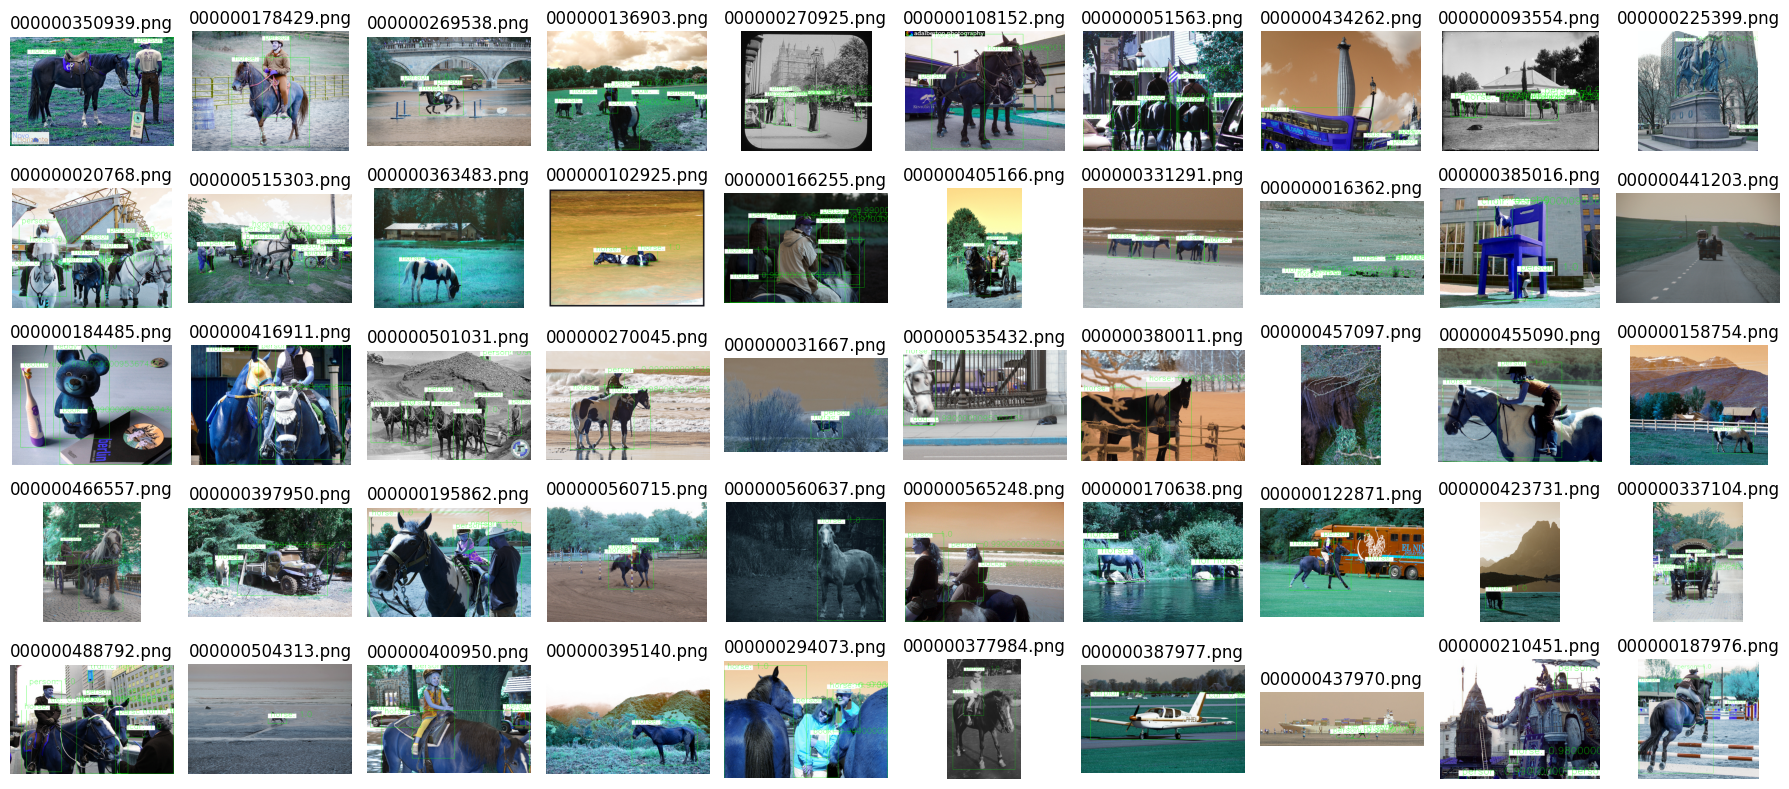

In [ ]:
show_images(output_path)

## YOLOv11 tasks [10 points]

In this section, you will focus on finetuning the [YOLOv11](https://github.com/ultralytics/ultralytics) (You Only Look Once) model for object detection on Cryo-Electron Microscopy (Cryo-EM) data, widely used in structural biology for capturing high-resolution images of molecular complexes. The task involves detecting particles within noisy and low-contrast Cryo-EM images, presenting a challenge typical of this data type. Students will implement the YOLOv11 model, train it using Cryo-EM datasets, and evaluate its performance using metrics like precision and recall. This hands-on exercise will help students understand how to fine-tune object detection models for specialized applications in scientific imaging.

### Dataset

The images for this section are present under `CryoEM/images` and the corresponding annotation file for each image is present in `CryoEM/particle_coordinates`. For this assignment we will only use the first three columns of the annotation file.

#### YOLO Data Format

In order to train YOLO model for our data, we will first have to restructure our data to match with YOLO's requirements, which can be found [here](https://docs.ultralytics.com/datasets/detect/). In brief each image needs a corresponding text file containing normalized bounding box coordinates and size, in corresponding directories based on wheather it is training/validation/testing splits.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00


In [ ]:
import glob
import os
import pandas as pd
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
ANNOTATION_DIR = HW3_ROOT_PATH + "CryoEM/particle_coordinates/"

def convert_to_YOLO_format(file_name, IMAGE_DIR, YOLO_anno_dir):
    image_path = IMAGE_DIR + file_name + ".jpg"
    anno_path = ANNOTATION_DIR + file_name + ".csv"
    orig_image = Image.open(image_path)
    img_w, img_h = orig_image.size  # Get image dimensions
    df = pd.read_csv(anno_path)
    df_values = df.iloc[:, :3].values  # Slice first three columns (x, y, d)
    with open(YOLO_anno_dir + file_name + ".txt", "w") as f:
        for x, y, d in df_values:
            class_int = 0
            x_norm = x / img_w
            y_norm = y / img_h
            w_norm = d / img_w
            h_norm = d / img_h
            f.write(f"{class_int} {x_norm} {y_norm} {w_norm} {h_norm}\n")


In [ ]:
TRAIN_IMAGE_DIR = HW3_ROOT_PATH + "CryoEM/images/train/"
TRAIN_YOLO_anno_dir = "CryoEM/labels/train/" # Directory to store converted labels

VAL_IMAGE_DIR = HW3_ROOT_PATH + "CryoEM/images/val/"
VAL_YOLO_anno_dir = "CryoEM/labels/val/" # Directory to store converted labels

TEST_IMAGE_DIR = HW3_ROOT_PATH + "CryoEM/images/test/"
TEST_YOLO_anno_dir = "CryoEM/labels/test/" # Directory to store converted labels

for directory in [TRAIN_YOLO_anno_dir, VAL_YOLO_anno_dir, TEST_YOLO_anno_dir]:
    os.makedirs(directory, exist_ok=True)

file_names = os.listdir(TRAIN_IMAGE_DIR)
for file_path in file_names:
    file_name = file_path[:-4]
    convert_to_YOLO_format(file_name,TRAIN_IMAGE_DIR,TRAIN_YOLO_anno_dir)

file_names = os.listdir(VAL_IMAGE_DIR)
for file_path in file_names:
    file_name = file_path[:-4]
    convert_to_YOLO_format(file_name,VAL_IMAGE_DIR,VAL_YOLO_anno_dir)

file_names = os.listdir(TEST_IMAGE_DIR)
for file_path in file_names:
    file_name = file_path[:-4]
    convert_to_YOLO_format(file_name,TEST_IMAGE_DIR,TEST_YOLO_anno_dir)

You will have to generate .yaml file as given in the YOLO [docs](https://docs.ultralytics.com/datasets/detect/).

In [ ]:
# Create a data configuration file for YOLO
data_config = f"""
path: {HW3_ROOT_PATH}
train: CryoEM/images/train
val: CryoEM/images/val
test: CryoEM/images/test

names:
  0: particle
"""

with open('cryoem.yaml', 'w') as f:
    f.write(data_config)

In [ ]:
%cat cryoem.yaml


path: /gdrive/MyDrive/AMS563/AMS563-25S-HW3/
train: CryoEM/images/train
val: CryoEM/images/val
test: CryoEM/images/test

names:
  0: particle


In [ ]:
## USE THIS SPACE TO FIINETUNE THE YOLOv11 MODEL

# Load a model
model = YOLO("yolo11m.pt")

# Train the model
results = model.train(
    data="cryoem.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    project="/content",
    name="yolo_train"
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cryoem.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

In [ ]:
# Evaluate the model
metrics = model.val()

# Print specific metrics
print("Class indices with average precision:", metrics.ap_class_index)
print("Average precision for all classes:", metrics.box.all_ap)
print("Average precision:", metrics.box.ap)
print("Average precision at IoU=0.50:", metrics.box.ap50)
print("Class indices for average precision:", metrics.box.ap_class_index)
print("F1 score:", metrics.box.f1)
print("Mean average precision:", metrics.box.map)
print("Mean average precision at IoU=0.50:", metrics.box.map50)
print("Mean average precision at IoU=0.75:", metrics.box.map75)
print("Mean average precision for different IoU thresholds:", metrics.box.maps)

print("Mean precision:", metrics.box.mp)
print("Mean recall:", metrics.box.mr)
print("Precision:", metrics.box.p)

print("Recall:", metrics.box.r)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 358.7±34.9 MB/s, size: 1658.1 KB)
val: Scanning /gdrive/MyDrive/AMS563/AMS563-25S-HW3/CryoEM/labels/val.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 4.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4s/it 4.8s
                   all         17      10134      0.937      0.472      0.455      0.324
Speed: 20.6ms preprocess, 47.6ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /gdrive/MyDrive/AMS563/AMS563-25S-HW3/part1/runs/detect/val
Class indices with average precision: [0]
Average precision for all classes: [[    0.45482     0.45453     0.44454      0.4424     0.42754     0.40688     0.34187     0.21064    0.059251   0.0015895]]
Average precision: